In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA: True
GPU: Tesla T4


In [1]:
import torch
import huggingface_hub

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("HF Hub:", huggingface_hub.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA: True
HF Hub: 1.23.0
GPU: Tesla T4


In [2]:
%cd /content

!rm -rf DiffusionPen
!git clone https://github.com/koninik/DiffusionPen.git

%cd /content/DiffusionPen
!ls

/content
Cloning into 'DiffusionPen'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 199 (delta 107), reused 97 (delta 97), pack-reused 83 (from 1)
Receiving objects: 100% (199/199), 12.74 MiB | 19.59 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/DiffusionPen
feature_extractor.py  LICENSE		      unet.py
imgs		      README.md		      utils
index2letter.json     style_encoder_train.py  writers_dict_test.json
letter2index.json     train.py		      writers_dict_train.json


In [3]:
from pathlib import Path

repo = Path("/content/DiffusionPen")

print("requirements.txt:", (repo / "requirements.txt").exists())

if (repo / "requirements.txt").exists():
    print((repo / "requirements.txt").read_text())

requirements.txt: False


In [4]:
from huggingface_hub import snapshot_download

hf_path = snapshot_download(
    repo_id="konnik/DiffusionPen",
    local_dir="/content/DiffusionPen_HF"
)

print("Скачано в:", hf_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Скачано в: /content/DiffusionPen_HF


In [5]:
!find /content/DiffusionPen_HF -maxdepth 3 -type f | head -100

/content/DiffusionPen_HF/saved_iam_data/test_word_IAM.pt
/content/DiffusionPen_HF/saved_iam_data/train_word_IAM.pt
/content/DiffusionPen_HF/README.md
/content/DiffusionPen_HF/.cache/huggingface/.gitignore
/content/DiffusionPen_HF/.cache/huggingface/CACHEDIR.TAG
/content/DiffusionPen_HF/style_models/gnhk_style_diffusionpen.pth
/content/DiffusionPen_HF/style_models/iam_style_diffusionpen_class.pth
/content/DiffusionPen_HF/style_models/iam_style_diffusionpen_triplet.pth
/content/DiffusionPen_HF/style_models/iam_style_diffusionpen.pth
/content/DiffusionPen_HF/diffusionpen_iam_model_path/models/optim.pt
/content/DiffusionPen_HF/diffusionpen_iam_model_path/models/ema_ckpt.pt
/content/DiffusionPen_HF/diffusionpen_iam_model_path/models/ckpt.pt
/content/DiffusionPen_HF/.gitattributes


In [6]:
import shutil
from pathlib import Path

src = Path("/content/DiffusionPen_HF")
dst = Path("/content/DiffusionPen")

for folder in [
    "saved_iam_data",
    "style_models",
    "diffusionpen_iam_model_path"
]:
    source = src / folder
    target = dst / folder

    if target.exists():
        shutil.rmtree(target)

    shutil.copytree(source, target)
    print("OK:", target)

OK: /content/DiffusionPen/saved_iam_data
OK: /content/DiffusionPen/style_models
OK: /content/DiffusionPen/diffusionpen_iam_model_path


In [7]:
%cd /content/DiffusionPen

from pathlib import Path

checks = [
    "saved_iam_data/train_word_IAM.pt",
    "saved_iam_data/test_word_IAM.pt",
    "style_models/iam_style_diffusionpen.pth",
    "diffusionpen_iam_model_path/models/ckpt.pt",
    "diffusionpen_iam_model_path/models/ema_ckpt.pt",
]

for x in checks:
    print(x, "->", Path(x).exists())

/content/DiffusionPen
saved_iam_data/train_word_IAM.pt -> True
saved_iam_data/test_word_IAM.pt -> True
style_models/iam_style_diffusionpen.pth -> True
diffusionpen_iam_model_path/models/ckpt.pt -> True
diffusionpen_iam_model_path/models/ema_ckpt.pt -> True


In [8]:
from pathlib import Path

for filename in ["train.py", "style_encoder_train.py"]:
    print("\n==========", filename, "==========")
    text = Path(filename).read_text(errors="ignore")

    for line in text.splitlines():
        s = line.strip()
        if s.startswith("import ") or s.startswith("from "):
            print(s)


========== train.py ==========
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader, random_split
import torchvision
from tqdm import tqdm
from torch import optim
import copy
import argparse
import uuid
import json
from diffusers import AutoencoderKL, DDIMScheduler
import random
from unet import UNetModel
import wandb
from torchvision import transforms
from feature_extractor import ImageEncoder
from utils.iam_dataset import IAMDataset
from utils.GNHK_dataset import GNHK_Dataset
from utils.auxilary_functions import *
from torchvision.utils import save_image
from torch.nn import DataParallel
from transformers import CanineModel, CanineTokenizer

========== style_encoder_train.py ==========
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
from PIL import Image, ImageOps
from os.p

In [9]:
!python train.py --help

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/diffusers/utils/import_utils.py", line 1015, in _get_module
    return importlib.import_module("." + module_name, self.__name__)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 1023, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.13/dist-packages/diffusers/loaders/peft.py", li

In [1]:
!pip install -q --no-cache-dir \
    "huggingface-hub>=0.34,<2.0" \
    "transformers>=4.55,<5" \
    "diffusers==0.35.2" \
    "accelerate>=1.0" \
    "safetensors>=0.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 200.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 303.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 358.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 331.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.


In [1]:
import sys
import torch
import transformers
import diffusers
import huggingface_hub
import tokenizers

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("diffusers:", diffusers.__version__)
print("HF Hub:", huggingface_hub.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
CUDA: True
GPU: Tesla T4
transformers: 4.57.6
tokenizers: 0.22.2
diffusers: 0.35.2
HF Hub: 0.36.2


In [2]:
%cd /content/DiffusionPen
!python train.py --help

/content/DiffusionPen
I0000 00:00:1791267513.626465    8230 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791267518.077959    8230 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
usage: train.py [-h] [--epochs EPOCHS] [--batch_size BATCH_SIZE]
                [--num_workers NUM_WORKERS] [--model_name MODEL_NAME]
                [--level LEVEL] [--img_size IMG_SIZE] [--dataset DATASET]
                [--channels CHANNELS] [--emb_dim EMB_DIM]
                [--num_heads NUM_HEADS] [--num_res_blocks NUM_RES_BLOCKS]
                [--save_path SAVE_PATH] [--device DEVICE]
                [--wandb_log WANDB_LOG] [--color COLOR] [--unet UNET]
                [--latent LA

In [3]:
import torch
from pathlib import Path

print("PyTorch CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

root = Path("/content/DiffusionPen")

paths = [
    root / "saved_iam_data/train_word_IAM.pt",
    root / "saved_iam_data/test_word_IAM.pt",
    root / "style_models/iam_style_diffusionpen.pth",
    root / "diffusionpen_iam_model_path/models/ckpt.pt",
    root / "diffusionpen_iam_model_path/models/ema_ckpt.pt",
]

for p in paths:
    print(p.name, "->", p.exists())

PyTorch CUDA: True
GPU: Tesla T4
train_word_IAM.pt -> True
test_word_IAM.pt -> True
iam_style_diffusionpen.pth -> True
ckpt.pt -> True
ema_ckpt.pt -> True


In [5]:
from pathlib import Path

path = Path("/content/DiffusionPen/utils/word_dataset.py")

text = path.read_text()

old = "data = torch.load(save_file)"
new = "data = torch.load(save_file, weights_only=False)"

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Исправлено.")
else:
    print("Строка уже изменена или код отличается.")

Исправлено.


In [7]:
%cd /content/DiffusionPen

!python train.py \
    --save_path ./diffusionpen_iam_model_path \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda

/content/DiffusionPen
I0000 00:00:1791267813.941613    9505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791267818.805415    9505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading IAM
^C


In [ ]:
import torch
import time
import os
import psutil

path = "/content/DiffusionPen/saved_iam_data/train_word_IAM.pt"

print("Файл существует:", os.path.exists(path))
print("Размер файла, GB:", round(os.path.getsize(path) / 1024**3, 3))

ram = psutil.virtual_memory()
print("RAM всего, GB:", round(ram.total / 1024**3, 2))
print("RAM доступно, GB:", round(ram.available / 1024**3, 2))

print("\nНачинаю torch.load...")
t = time.time()

data = torch.load(
    path,
    map_location="cpu",
    weights_only=False
)

print("\nУСПЕХ")
print("Время:", round(time.time() - t, 1), "сек")
print("Тип:", type(data))

try:
    print("len:", len(data))
except Exception as e:
    print("len определить нельзя:", e)

ram = psutil.virtual_memory()
print("RAM после загрузки, GB:", round(ram.available / 1024**3, 2))

Файл существует: True
Размер файла, GB: 4.932
RAM всего, GB: 12.67
RAM доступно, GB: 11.22

Начинаю torch.load...


In [1]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
lines = p.read_text().splitlines()

for i in range(570, 680):
    print(f"{i+1}: {lines[i]}")

571:     parser.add_argument('--img_feat', type=bool, default=True)
572:     parser.add_argument('--interpolation', type=bool, default=False)
573:     parser.add_argument('--dataparallel', type=bool, default=False)
574:     parser.add_argument('--load_check', type=bool, default=False)
575:     parser.add_argument('--sampling_word', type=bool, default=False) 
576:     parser.add_argument('--mix_rate', type=float, default=None)
577:     parser.add_argument('--style_path', type=str, default='./style_models/iam_style_diffusionpen.pth')
578:     parser.add_argument('--stable_dif_path', type=str, default='./stable-diffusion-v1-5')
579:     parser.add_argument('--train_mode', type=str, default='train', help='train, sampling')
580:     parser.add_argument('--sampling_mode', type=str, default='single_sampling', help='single_sampling (generate single image), paragraph (generate paragraph)')
581:     
582:     args = parser.parse_args()
583:     
584:     print('torch version', torch.__version__)

In [2]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
lines = p.read_text().splitlines()

for i in range(680, min(910, len(lines))):
    print(f"{i+1}: {lines[i]}")

681:     
682:     if args.load_check==True:
683:         unet.load_state_dict(torch.load(f'{args.save_path}/models/ckpt.pt'))
684:         optimizer.load_state_dict(torch.load(f'{args.save_path}/models/optim.pt'))
685:         ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt'))
686:         print('Loaded models and optimizer')
687:     
688:     if args.latent==True:
689:         print('VAE is true')
690:         vae = AutoencoderKL.from_pretrained(args.stable_dif_path, subfolder="vae")
691:         vae = DataParallel(vae, device_ids=device_ids)
692:         vae = vae.to(args.device)
693:         # Freeze vae and text_encoder
694:         vae.requires_grad_(False)
695:     else:
696:         vae = None
697: 
698:     #add DDIM scheduler from huggingface
699:     ddim = DDIMScheduler.from_pretrained(args.stable_dif_path, subfolder="scheduler")
700:     
701:     #### STYLE ####
702:     feature_extractor = ImageEncoder(model_name='mobilenetv2_100', num_classes

In [3]:
from pathlib import Path

path = Path("/content/DiffusionPen/train.py")
text = path.read_text()

start = text.index("    if args.dataset == 'iam':")
end = text.index("    character_classes =", start)

new_block = """    if args.dataset == 'iam':
        print('loading IAM')
        iam_folder = './iam_data/words'
        myDataset = IAMDataset
        style_classes = 339

        if args.train_mode == 'train':
            if args.level == 'word':
                train_data = myDataset(
                    iam_folder, 'train', 'word',
                    fixed_size=(1 * 64, 256),
                    tokenizer=None,
                    text_encoder=None,
                    feat_extractor=None,
                    transforms=transform,
                    args=args
                )
            else:
                train_data = myDataset(
                    iam_folder, 'train', 'word',
                    fixed_size=(1 * 64, 256),
                    tokenizer=None,
                    text_encoder=None,
                    feat_extractor=None,
                    transforms=transform,
                    args=args
                )

            print('train data', len(train_data))

            test_size = args.batch_size
            rest = len(train_data) - test_size

            test_data, _ = random_split(
                train_data,
                [test_size, rest],
                generator=torch.Generator().manual_seed(42)
            )

            train_loader = DataLoader(
                train_data,
                batch_size=args.batch_size,
                shuffle=True,
                num_workers=4
            )

            test_loader = DataLoader(
                test_data,
                batch_size=args.batch_size,
                shuffle=False,
                num_workers=4
            )

        else:
            print('Sampling mode: skipping IAM dataset loading')
            train_loader = None
            test_loader = None

    elif args.dataset == 'gnhk':
        print('loading GNHK')
        myDataset = GNHK_Dataset
        dataset_folder = 'path/to/GNHK'
        style_classes = 515

        if args.train_mode == 'train':
            train_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.5, 0.5, 0.5),
                    (0.5, 0.5, 0.5)
                )
            ])

            train_data = myDataset(
                dataset_folder, 'train', 'word',
                fixed_size=(1 * 64, 256),
                tokenizer=None,
                text_encoder=None,
                feat_extractor=None,
                transforms=train_transform,
                args=args
            )

            test_size = args.batch_size
            rest = len(train_data) - test_size

            test_data, _ = random_split(
                train_data,
                [test_size, rest],
                generator=torch.Generator().manual_seed(42)
            )

            train_loader = DataLoader(
                train_data,
                batch_size=args.batch_size,
                shuffle=True,
                num_workers=4
            )

            test_loader = DataLoader(
                test_data,
                batch_size=args.batch_size,
                shuffle=False,
                num_workers=4
            )

        else:
            print('Sampling mode: skipping GNHK dataset loading')
            train_loader = None
            test_loader = None

"""

text = text[:start] + new_block + text[end:]
path.write_text(text)

print("Готово: dataset loading отключён для sampling.")

Готово: dataset loading отключён для sampling.


In [4]:
!python -m py_compile /content/DiffusionPen/train.py
print("OK")

OK


In [7]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
    local_dir="/content/DiffusionPen/stable-diffusion-v1-5",
    allow_patterns=[
        "vae/*",
        "scheduler/*"
    ]
)

print("Готово")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Готово


In [9]:
from pathlib import Path

path = Path("/content/DiffusionPen/train.py")
text = path.read_text()

old = """ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt'))"""
new = """ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt', map_location=args.device))"""

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Исправлено: EMA checkpoint теперь загружается на cuda:0")
else:
    print("Строка не найдена или уже исправлена")

Исправлено: EMA checkpoint теперь загружается на cuda:0


In [11]:
from pathlib import Path

path = Path("/content/DiffusionPen/train.py")
text = path.read_text()

old = """ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt'))"""
new = """ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt', map_location=args.device))"""

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Исправлено: EMA checkpoint теперь загружается на cuda:0")
else:
    print("Строка не найдена или уже исправлена")

Строка не найдена или уже исправлена


In [13]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
text = p.read_text()

text = text.replace(
    "s = random.randint(0, 339) #index for style class",
    "s = 214 # fixed style for reproduction"
)

p.write_text(text)

print("Style fixed to 214")

Style fixed to 214


In [14]:
import os

targets = {
    "r02-038-00-04.png",
    "r02-038-03-01.png",
    "r02-038-02-04.png",
    "r02-038-05-06.png",
    "r02-038-02-10.png",
}

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f in targets:
            print(os.path.join(root, f))

In [15]:
from pathlib import Path
import shutil

base = Path("/content")

targets = {
    "r02-038-00-04.png": "r02/r02-038/r02-038-00-04.png",
    "r02-038-03-01.png": "r02/r02-038/r02-038-03-01.png",
    "r02-038-02-04.png": "r02/r02-038/r02-038-02-04.png",
    "r02-038-05-06.png": "r02/r02-038/r02-038-05-06.png",
    "r02-038-02-10.png": "r02/r02-038/r02-038-02-10.png",
}

dest_root = Path("/content/DiffusionPen/iam_data/words")

for filename, relative_path in targets.items():
    found = [
        p for p in base.rglob(filename)
        if "DiffusionPen/iam_data/words" not in str(p)
    ]

    if not found:
        print("НЕ НАЙДЕН:", filename)
        continue

    src = found[0]
    dst = dest_root / relative_path

    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

    print("OK:", src, "->", dst)

НЕ НАЙДЕН: r02-038-00-04.png
НЕ НАЙДЕН: r02-038-03-01.png
НЕ НАЙДЕН: r02-038-02-04.png
НЕ НАЙДЕН: r02-038-05-06.png
НЕ НАЙДЕН: r02-038-02-10.png


In [12]:
%cd /content/DiffusionPen

!python train.py \
    --save_path ./diffusionpen_iam_model_path \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0

/content/DiffusionPen
I0000 00:00:1791268936.242314   14384 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791268938.919216   14384 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading IAM
Sampling mode: skipping IAM dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: text
style 231
five_styles [['r03/r03-050/r03-050-00-09.png', '662', 'with'], ['r03/r03-050/r03-050-03-06.png', '662', 'corners'], ['r03/r03-050/r03-050-00-04.png', '662', 'dusty'], ['r03/r03-050/r03-050-00-07.png', '662', 'office'], ['r03/r03-050/r03-050-04-00.png', '662', 'grey']]
Traceback (most recent call last):
  File "/content/DiffusionPe

In [16]:
%cd /content

!wget -q --show-progress \
  https://github.com/sayakpaul/Handwriting-Recognizer-in-Keras/releases/download/v1.0.0/IAM_Words.zip \
  -O IAM_Words.zip

!ls -lh IAM_Words.zip

/content
IAM_Words.zip       100%[===================>] 783.77M  14.6MB/s    in 46s     
-rw-r--r-- 1 root root 784M Dec  8  2021 IAM_Words.zip


In [17]:
!unzip -q IAM_Words.zip -d /content/

!ls -lh /content/IAM_Words/

total 788M
-rw-r--r-- 1 root root 783M Jan 22  2021 words.tgz
-rw-r--r-- 1 root root 5.1M Mar  2  2004 words.txt


In [18]:
from pathlib import Path
import tarfile

archive = "/content/IAM_Words/words.tgz"
dest = Path("/content/DiffusionPen/iam_data/words")
dest.mkdir(parents=True, exist_ok=True)

with tarfile.open(archive, "r:gz") as tar:
    tar.extractall(dest)

print("IAM words распакован")

/tmp/ipykernel_10159/3224880362.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest)


IAM words распакован


In [19]:
from pathlib import Path

root = Path("/content/DiffusionPen/iam_data/words")

targets = [
    "r02/r02-038/r02-038-00-04.png",
    "r02/r02-038/r02-038-03-01.png",
    "r02/r02-038/r02-038-02-04.png",
    "r02/r02-038/r02-038-05-06.png",
    "r02/r02-038/r02-038-02-10.png",
]

for x in targets:
    p = root / x
    print(p.exists(), x)

True r02/r02-038/r02-038-00-04.png
True r02/r02-038/r02-038-03-01.png
True r02/r02-038/r02-038-02-04.png
True r02/r02-038/r02-038-05-06.png
True r02/r02-038/r02-038-02-10.png


In [21]:
from pathlib import Path

path = Path("/content/DiffusionPen/train.py")
text = path.read_text()

marker = 'if __name__ == "__main__":'

func = '''
def save_single_images(images, path, args=None):
    import os
    import torchvision

    os.makedirs(os.path.dirname(path), exist_ok=True)

    image = images[0].detach().cpu()

    # модель возвращает значения примерно в [-1, 1]
    image = (image + 1) / 2
    image = image.clamp(0, 1)

    torchvision.utils.save_image(image, path)
    print("Saved:", path)

'''

if "def save_single_images(" not in text:
    text = text.replace(marker, func + "\n" + marker)
    path.write_text(text)
    print("Функция save_single_images добавлена")
else:
    print("save_single_images уже существует")

Функция save_single_images добавлена


In [22]:
%cd /content/DiffusionPen

!python train.py \
    --save_path ./diffusionpen_iam_model_path \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5 \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0

/content/DiffusionPen
I0000 00:00:1791269668.220612   17451 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791269670.459597   17451 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading IAM
Sampling mode: skipping IAM dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: text
style 214
five_styles [['r02/r02-038/r02-038-04-01.png', '641', 'wondered'], ['r02/r02-038/r02-038-00-13.png', '641', 'blinked'], ['r02/r02-038/r02-038-01-00.png', '641', 'disdainfully'], ['r02/r02-038/r02-038-02-10.png', '641', 'jogged'], ['r02/r02-038/r02-038-03-04.png', '641', 'invitingly']]
Saved: ./image_samples/text_style_214.png
Word

Найдено: 2
text_style_214.png (256, 64)


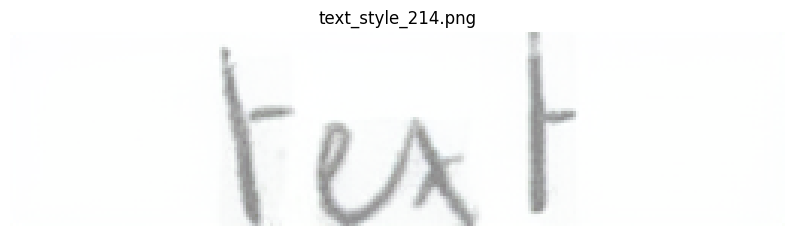

word_style_214.png (256, 64)


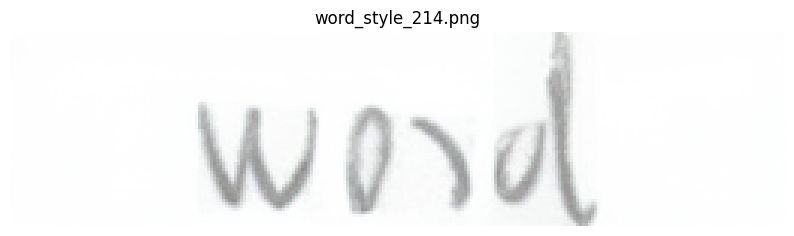

In [23]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

files = sorted(
    Path("/content/DiffusionPen/image_samples").glob("*style_214.png")
)

print("Найдено:", len(files))

for f in files:
    img = Image.open(f)

    print(f.name, img.size)

    plt.figure(figsize=(10, 3))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f.name)
    plt.show()

In [24]:
from pathlib import Path

path = Path("/content/DiffusionPen/train.py")
text = path.read_text()

text = text.replace(
    "x_text = ['text', 'word']",
    "x_text = ['текст', 'привет', 'қазақ', 'Әлем']"
)

path.write_text(text)

print("Тексты заменены")

Тексты заменены


In [25]:
%cd /content/DiffusionPen

!python train.py \
    --save_path ./diffusionpen_iam_model_path \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5 \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0

/content/DiffusionPen
I0000 00:00:1791269820.460309   18103 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791269822.650838   18103 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading IAM
Sampling mode: skipping IAM dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: текст
style 214
five_styles [['r02/r02-038/r02-038-04-08.png', '641', 'remains'], ['r02/r02-038/r02-038-04-06.png', '641', 'Probably'], ['r02/r02-038/r02-038-04-04.png', '641', 'contained'], ['r02/r02-038/r02-038-03-01.png', '641', 'shiny'], ['r02/r02-038/r02-038-05-07.png', '641', 'files']]
Saved: ./image_samples/текст_style_214.png
Word: приве

текст -> True


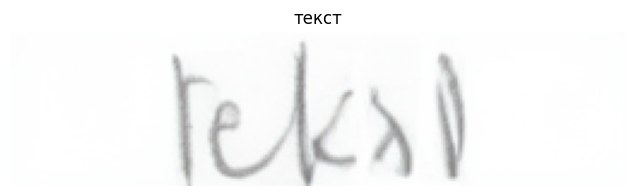

привет -> True


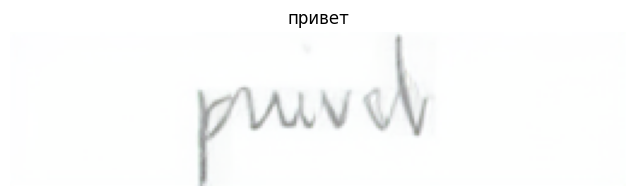

қазақ -> True


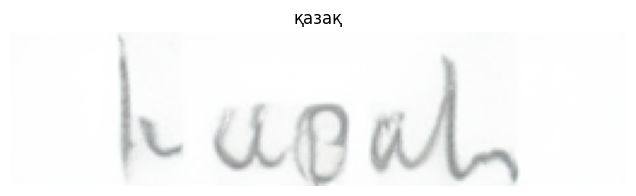

Әлем -> True


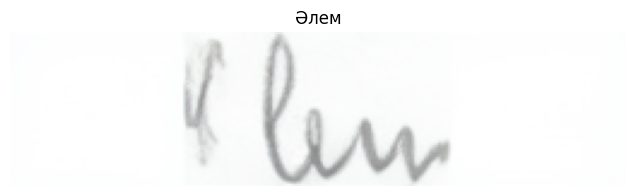

In [26]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

folder = Path("/content/DiffusionPen/image_samples")

for word in ['текст', 'привет', 'қазақ', 'Әлем']:
    f = folder / f"{word}_style_214.png"

    print(word, "->", f.exists())

    if f.exists():
        img = Image.open(f)

        plt.figure(figsize=(8, 2))
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(word)
        plt.show()

In [27]:
from pathlib import Path

for root in [Path("/content"), Path("/content/drive/MyDrive")]:
    if not root.exists():
        continue

    for p in root.rglob("*"):
        if p.is_file() and (
            "hkr" in p.name.lower()
            or p.name.lower() in ["ann.zip", "img.zip"]
        ):
            print(p)

In [28]:
from pathlib import Path

p = Path("/content/DiffusionPen/utils")

for f in p.glob("*gnhk*"):
    print("\nFILE:", f)
    print("=" * 80)
    print(f.read_text()[:12000])

In [29]:
!grep -R -n "class GNHK" /content/DiffusionPen

/content/DiffusionPen/utils/GNHK_dataset.py:10:class GNHK_Dataset(WordLineDataset):


In [30]:
from pathlib import Path

for f in Path("/content/DiffusionPen").rglob("*.py"):
    txt = f.read_text(errors="ignore")
    if "class GNHK" in txt:
        print("FILE:", f)
        print(txt[:15000])

FILE: /content/DiffusionPen/utils/GNHK_dataset.py
import numpy as np 
from skimage import io as img_io
from utils.word_dataset import WordLineDataset
from utils.auxilary_functions import image_resize_PIL, centered_PIL
from PIL import Image, ImageOps
import json
import os
import string

class GNHK_Dataset(WordLineDataset):
    def __init__(self, basefolder, subset, segmentation_level, fixed_size,  tokenizer, text_encoder, feat_extractor, transforms, args):
        super().__init__(basefolder, subset, segmentation_level, fixed_size, tokenizer, text_encoder, feat_extractor, transforms, args)
        self.setname = 'GNHK'
        self.trainset_file = f'{self.basefolder}/GNHK_words_train.txt'
        self.testset_file = f'{self.basefolder}/GNHK_words_test.txt'
        self.word_path = self.basefolder
        
        #self.stopwords_path = '{}/{}/iam-stopwords'.format(self.basefolder, self.setname)
        super().__finalize__()

    def main_loader(self, subset, segmentation_level) -> list

In [33]:
from pathlib import Path

candidates = []

for root in [Path("/content"), Path("/content/drive/MyDrive")]:
    if root.exists():
        candidates += list(root.rglob("ann.zip"))

for p in candidates:
    print(p)

/content/drive/MyDrive/HKR_project/ann.zip
/content/drive/MyDrive/HKR_project/ann.zip


In [32]:
from google.colab import drive
drive.mount('/content/drive')
!find /content/drive/MyDrive -maxdepth 3 -type f \( \
    -iname "*ann*.zip" -o \
    -iname "*img*.zip" -o \
    -iname "*hkr*.zip" \
\) 2>/dev/null | head -50

Mounted at /content/drive
/content/drive/MyDrive/HKR_project/img.zip
/content/drive/MyDrive/HKR_project/ann.zip


In [34]:
from pathlib import Path

folder = Path("/content/drive/MyDrive/HKR_project")

for f in folder.glob("*"):
    print(f.name, round(f.stat().st_size / 1024**3, 2), "GB")

img.zip 0.66 GB
ann.zip 0.02 GB
results 0.0 GB
results_pretrained 0.0 GB


In [35]:
import zipfile
import json
from pathlib import Path

ANN_ZIP = "/content/drive/MyDrive/HKR_project/ann.zip"

with zipfile.ZipFile(ANN_ZIP) as z:
    names = [
        n for n in z.namelist()
        if n.endswith(".json")
        and "__MACOSX" not in n
        and "/._" not in n
    ]

    print("Настоящих JSON:", len(names))

    for name in names[:5]:
        obj = json.loads(z.read(name))

        print("\n" + "=" * 80)
        print("FILE:", name)
        print("TYPE:", type(obj))

        if isinstance(obj, dict):
            print("KEYS:", list(obj.keys()))
            print(json.dumps(obj, ensure_ascii=False, indent=2)[:3000])
        else:
            print(str(obj)[:3000])

Настоящих JSON: 140355

FILE: ann/746_005_006.json
TYPE: <class 'dict'>
KEYS: ['name', 'description']
{
  "name": "746_005_006.jpg",
  "description": "болсақ"
}

FILE: ann/380_015_002.json
TYPE: <class 'dict'>
KEYS: ['name', 'description']
{
  "name": "380_015_002.jpg",
  "description": "арттыру"
}

FILE: ann/1812_002_002.json
TYPE: <class 'dict'>
KEYS: ['name', 'description']
{
  "name": "1812_002_002.jpg",
  "description": "Осында"
}

FILE: ann/1649_007_008.json
TYPE: <class 'dict'>
KEYS: ['name', 'description']
{
  "name": "1649_007_008.jpg",
  "description": "бет"
}

FILE: ann/1560_013_001.json
TYPE: <class 'dict'>
KEYS: ['name', 'description']
{
  "name": "1560_013_001.jpg",
  "description": "тұрақты"
}


In [36]:
import zipfile
import json
from collections import Counter, defaultdict

ANN_ZIP = "/content/drive/MyDrive/HKR_project/ann.zip"

prefix_counts = Counter()
examples = defaultdict(list)

with zipfile.ZipFile(ANN_ZIP) as z:
    names = [
        n for n in z.namelist()
        if n.endswith(".json")
        and "__MACOSX" not in n
        and "/._" not in n
    ]

    for name in names:
        obj = json.loads(z.read(name))

        image_name = obj["name"]
        text = obj["description"]

        stem = image_name.rsplit(".", 1)[0]
        parts = stem.split("_")

        prefix = parts[0]

        prefix_counts[prefix] += 1

        if len(examples[prefix]) < 5:
            examples[prefix].append((image_name, text))

print("Всего первых ID:", len(prefix_counts))

print("\nСамые крупные группы:")
for prefix, cnt in prefix_counts.most_common(20):
    print("\nID:", prefix, "| images:", cnt)
    for x in examples[prefix]:
        print("   ", x)

Всего первых ID: 1901

Самые крупные группы:

ID: word | images: 24989
    ('word_croped_Скан_20200929_29_6_2.jpg', 'береді.')
    ('word_croped_Скан_20200929 (18)_15_4.jpg', 'тандыратын')
    ('word_croped_Скан_20201006_9 (5)_15_1.jpg', 'өмірін')
    ('word_croped_Скан_20200929_7 (6)_19_1.jpg', 'құны')
    ('word_croped_Скан_20200929_3 (22)_4_4.jpg', 'көп')

ID: 1538 | images: 187
    ('1538_019_006.jpg', 'кейіннен')
    ('1538_018_006.jpg', 'даму')
    ('1538_028_004.jpg', 'қолдаудың')
    ('1538_029_004.jpg', 'мен')
    ('1538_021_001.jpg', 'төмен')

ID: 1700 | images: 176
    ('1700_012_004.jpg', 'едім')
    ('1700_013_004.jpg', 'себебі')
    ('1700_009_002.jpg', 'үшін')
    ('1700_008_002.jpg', 'шабар')
    ('1700_022_006.jpg', 'бағамы')

ID: 428 | images: 173
    ('428_007_002.jpg', 'жалпы')
    ('428_006_002.jpg', 'ғұрып ,')
    ('428_015_001.jpg', 'дегеніміз')
    ('428_014_001.jpg', 'суб мәдениет')
    ('428_016_008.jpg', 'ортасынан')

ID: 876 | images: 173
    ('876_007_002.j

In [37]:
import numpy as np

counts = np.array(list(prefix_counts.values()))

print("Количество групп:", len(counts))
print("min:", counts.min())
print("median:", np.median(counts))
print("mean:", round(counts.mean(), 2))
print("max:", counts.max())

for threshold in [5, 10, 20, 50, 100]:
    print(
        f"Групп с >= {threshold} изображениями:",
        (counts >= threshold).sum()
    )

Количество групп: 1901
min: 1
median: 59.0
mean: 73.83
max: 24989
Групп с >= 5 изображениями: 1852
Групп с >= 10 изображениями: 1791
Групп с >= 20 изображениями: 1659
Групп с >= 50 изображениями: 1122
Групп с >= 100 изображениями: 258


In [38]:
largest_prefix = prefix_counts.most_common(1)[0][0]

print("Самая большая группа:", largest_prefix)
print("Размер:", prefix_counts[largest_prefix])

with zipfile.ZipFile(ANN_ZIP) as z:
    shown = 0

    for name in names:
        obj = json.loads(z.read(name))
        image_name = obj["name"]

        if image_name.split("_")[0] == largest_prefix:
            print(image_name, "->", obj["description"])
            shown += 1

            if shown >= 30:
                break

Самая большая группа: word
Размер: 24989
word_croped_Скан_20200929_29_6_2.jpg -> береді.
word_croped_Скан_20200929 (18)_15_4.jpg -> тандыратын
word_croped_Скан_20201006_9 (5)_15_1.jpg -> өмірін
word_croped_Скан_20200929_7 (6)_19_1.jpg -> құны
word_croped_Скан_20200929_3 (22)_4_4.jpg -> көп
word_croped_Скан_20200925_2 (9)_7_6.jpg -> меттерді
word_croped_Скан_20201006_3 (2)_10_2.jpg -> арқылы
word_croped_Скан_20200929_8 (13)_0_2.jpg -> болсақ,
word_croped_Скан_20200929_8 (3)_6_4.jpg -> Мысалыға
word_croped_Скан_20200929_17_4_3.jpg -> компьютерлердің
word_croped_Скан_20200929_10_7_1.jpg -> әдістер
word_croped_Скан_20200929_7 (8)_23_2.jpg -> ясіз
word_croped_Скан_20200929_4 (8)_15_3.jpg -> болып
word_croped_Скан_20200925_30_4_1.jpg -> қажет
word_croped_Скан_20200930_3_16_1.jpg -> қадаға
word_croped_Скан_20201013_2_15_1.jpg -> лады .
word_croped_Скан_20200925_18 (8)_26_4.jpg -> деңгейі
word_croped_Скан_20200929_26 (5)_-1_2.jpg -> шамадағы
word_croped_Скан_20200929_21 (3)_18_2.jpg -> мұра
wo

In [39]:
from collections import Counter

parts_len = Counter()
first_parts = Counter()
second_parts = Counter()
third_parts = Counter()

with zipfile.ZipFile(ANN_ZIP) as z:
    for name in names:
        obj = json.loads(z.read(name))
        stem = obj["name"].rsplit(".", 1)[0]
        parts = stem.split("_")

        parts_len[len(parts)] += 1

        if len(parts) >= 1:
            first_parts[parts[0]] += 1
        if len(parts) >= 2:
            second_parts[parts[1]] += 1
        if len(parts) >= 3:
            third_parts[parts[2]] += 1

print("Количество частей имени:")
print(parts_len)

print("\nУникальных значений:")
print("part 1:", len(first_parts))
print("part 2:", len(second_parts))
print("part 3:", len(third_parts))

print("\nTOP part 1:")
print(first_parts.most_common(10))

Количество частей имени:
Counter({3: 115366, 7: 24242, 6: 747})

Уникальных значений:
part 1: 1901
part 2: 40
part 3: 20

TOP part 1:
[('word', 24989), ('1538', 187), ('1700', 176), ('428', 173), ('876', 173), ('361', 167), ('1569', 165), ('1200', 162), ('337', 161), ('1890', 158)]


In [40]:
import zipfile
import json
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import io

ANN_ZIP = "/content/drive/MyDrive/HKR_project/ann.zip"
IMG_ZIP = "/content/drive/MyDrive/HKR_project/img.zip"

TARGET_PREFIX = "1538"
N_SHOW = 12

# annotation: image_name -> text
selected = []

with zipfile.ZipFile(ANN_ZIP) as az:
    ann_names = [
        n for n in az.namelist()
        if n.endswith(".json")
        and "__MACOSX" not in n
        and "/._" not in n
    ]

    for n in ann_names:
        obj = json.loads(az.read(n))
        image_name = obj["name"]

        parts = image_name.rsplit(".", 1)[0].split("_")

        # Только основная часть HKR
        if len(parts) == 3 and parts[0] == TARGET_PREFIX:
            selected.append(
                (image_name, obj["description"])
            )

        if len(selected) >= N_SHOW:
            break

print("Выбрано:", len(selected))
print(selected)

Выбрано: 12
[('1538_019_006.jpg', 'кейіннен'), ('1538_018_006.jpg', 'даму'), ('1538_028_004.jpg', 'қолдаудың'), ('1538_029_004.jpg', 'мен'), ('1538_021_001.jpg', 'төмен'), ('1538_020_001.jpg', 'дами'), ('1538_010_003.jpg', 'ұлты'), ('1538_011_003.jpg', 'лікті'), ('1538_027_006.jpg', 'бизнес'), ('1538_026_006.jpg', 'түрлі'), ('1538_016_004.jpg', 'елдегі'), ('1538_017_004.jpg', 'Қазақстан')]


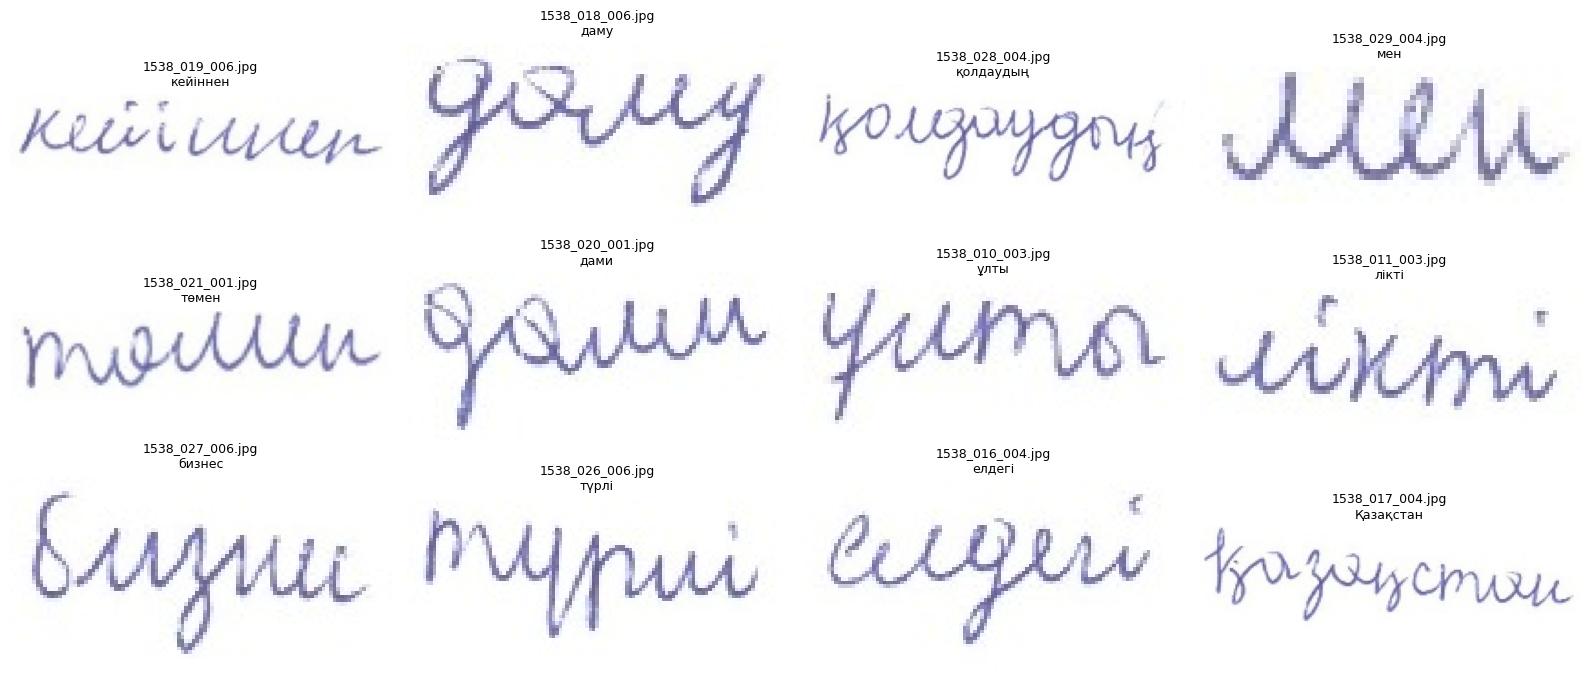

In [41]:
with zipfile.ZipFile(IMG_ZIP) as iz:

    # basename -> path inside ZIP
    image_index = {
        Path(n).name: n
        for n in iz.namelist()
        if not n.endswith("/")
        and "__MACOSX" not in n
        and "/._" not in n
    }

    fig, axes = plt.subplots(3, 4, figsize=(16, 7))
    axes = axes.flatten()

    for ax, (image_name, text) in zip(axes, selected):

        zip_path = image_index.get(image_name)

        if zip_path is None:
            ax.set_title("NOT FOUND")
            ax.axis("off")
            continue

        img = Image.open(
            io.BytesIO(iz.read(zip_path))
        ).convert("RGB")

        ax.imshow(img)
        ax.set_title(
            f"{image_name}\n{text}",
            fontsize=9
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [42]:
import zipfile
import json
import random
import os
from pathlib import Path
from collections import defaultdict

ANN_ZIP = "/content/drive/MyDrive/HKR_project/ann.zip"
IMG_ZIP = "/content/drive/MyDrive/HKR_project/img.zip"

OUT = Path("/content/HKR_diffusionpen")
TRAIN_DIR = OUT / "train_words"
TEST_DIR  = OUT / "test_words"

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)

groups = defaultdict(list)

with zipfile.ZipFile(ANN_ZIP) as az:

    for n in az.namelist():

        if (
            not n.endswith(".json")
            or "__MACOSX" in n
            or "/._" in n
        ):
            continue

        obj = json.loads(az.read(n))

        image_name = obj["name"]
        text = obj["description"].strip()

        stem = Path(image_name).stem
        parts = stem.split("_")

        if len(parts) != 3:
            continue

        if not text:
            continue

        style_group = parts[0]

        groups[style_group].append(
            (image_name, text)
        )

print("Style groups:", len(groups))
print("Images:", sum(len(v) for v in groups.values()))

Style groups: 1900
Images: 115366


In [43]:
eligible = {
    k: v
    for k, v in groups.items()
    if len(v) >= 50
}

print("Групп >=50:", len(eligible))

selected_styles = random.sample(
    list(eligible.keys()),
    10
)

print("Selected styles:", selected_styles)

Групп >=50: 1121
Selected styles: ['1337', '635', '506', '1559', '904', '1814', '1681', '354', '1040', '1005']


In [44]:
import zipfile
import random
import shutil
from pathlib import Path

random.seed(42)

OUT = Path("/content/HKR_diffusionpen")
TRAIN_DIR = OUT / "train_words"
TEST_DIR = OUT / "test_words"

# очищаем, если ячейка запускается повторно
if OUT.exists():
    shutil.rmtree(OUT)

TRAIN_DIR.mkdir(parents=True)
TEST_DIR.mkdir(parents=True)

# Используем уже выбранные группы
selected_styles = [
    '1337', '635', '506', '1559', '904',
    '1814', '1681', '354', '1040', '1005'
]

train_styles = selected_styles[:8]
test_styles = selected_styles[8:]

print("TRAIN styles:", train_styles)
print("TEST styles:", test_styles)

# максимум 50 изображений каждого стиля
train_items = []
test_items = []

for style in train_styles:
    items = groups[style].copy()
    random.shuffle(items)

    for image_name, text in items[:50]:
        train_items.append((image_name, text, style))

for style in test_styles:
    items = groups[style].copy()
    random.shuffle(items)

    for image_name, text in items[:50]:
        test_items.append((image_name, text, style))

print("\nTRAIN images:", len(train_items))
print("TEST images:", len(test_items))

TRAIN styles: ['1337', '635', '506', '1559', '904', '1814', '1681', '354']
TEST styles: ['1040', '1005']

TRAIN images: 400
TEST images: 100


In [45]:
IMG_ZIP = "/content/drive/MyDrive/HKR_project/img.zip"

needed = {
    image_name
    for image_name, _, _ in train_items + test_items
}

with zipfile.ZipFile(IMG_ZIP) as iz:

    image_index = {
        Path(n).name: n
        for n in iz.namelist()
        if not n.endswith("/")
        and "__MACOSX" not in n
        and "/._" not in n
    }

    found = 0
    missing = []

    train_names = {x[0] for x in train_items}

    for image_name in needed:

        source = image_index.get(image_name)

        if source is None:
            missing.append(image_name)
            continue

        target_dir = (
            TRAIN_DIR
            if image_name in train_names
            else TEST_DIR
        )

        with iz.open(source) as src:
            with open(target_dir / image_name, "wb") as dst:
                shutil.copyfileobj(src, dst)

        found += 1

print("Нужно:", len(needed))
print("Найдено:", found)
print("Не найдено:", len(missing))

if missing:
    print("Первые missing:", missing[:10])

Нужно: 500
Найдено: 500
Не найдено: 0


In [46]:
def make_manifest(items, image_dir, output_file):

    valid = []

    for image_name, text, style in items:

        if not (image_dir / image_name).exists():
            continue

        if " " in text:
            continue

        valid.append((image_name, text, style))

    with open(output_file, "w", encoding="utf-8") as f:
        for image_name, text, style in valid:
            f.write(f"{image_name} {text} {style}\n")

    return valid


train_valid = make_manifest(
    train_items,
    TRAIN_DIR,
    OUT / "GNHK_words_train.txt"
)

test_valid = make_manifest(
    test_items,
    TEST_DIR,
    OUT / "GNHK_words_test.txt"
)

print("TRAIN valid:", len(train_valid))
print("TEST valid:", len(test_valid))

print("\nПервые TRAIN:")
for x in train_valid[:10]:
    print(x)

TRAIN valid: 390
TEST valid: 91

Первые TRAIN:
('1337_008_004.jpg', 'кәсіпкерлік', '1337')
('1337_015_003.jpg', 'болсақ', '1337')
('1337_012_004.jpg', 'илап', '1337')
('1337_023_001.jpg', 'түсінігі', '1337')
('1337_015_002.jpg', 'келетін', '1337')
('1337_014_001.jpg', 'Ал', '1337')
('1337_004_004.jpg', 'жаңашылдықты', '1337')
('1337_010_003.jpg', 'дамыту', '1337')
('1337_006_001.jpg', 'пайда', '1337')
('1337_012_009.jpg', 'нәрсені', '1337')


In [47]:
print("\nСтруктура:")
print("train PNG/JPG:", len(list(TRAIN_DIR.glob("*"))))
print("test PNG/JPG:", len(list(TEST_DIR.glob("*"))))

print("\nTRAIN manifest:")
print(
    (OUT / "GNHK_words_train.txt")
    .read_text(encoding="utf-8")[:1000]
)


Структура:
train PNG/JPG: 400
test PNG/JPG: 100

TRAIN manifest:
1337_008_004.jpg кәсіпкерлік 1337
1337_015_003.jpg болсақ 1337
1337_012_004.jpg илап 1337
1337_023_001.jpg түсінігі 1337
1337_015_002.jpg келетін 1337
1337_014_001.jpg Ал 1337
1337_004_004.jpg жаңашылдықты 1337
1337_010_003.jpg дамыту 1337
1337_006_001.jpg пайда 1337
1337_012_009.jpg нәрсені 1337
1337_005_001.jpg келе 1337
1337_009_002.jpg түрлері 1337
1337_008_001.jpg айналысу 1337
1337_021_003.jpg айн 1337
1337_002_001.jpg насы 1337
1337_022_003.jpg инффақұр 1337
1337_002_005.jpg дегенді 1337
1337_020_003.jpg б. 1337
1337_013_002.jpg әрсені 1337
1337_005_005.jpg отырып 1337
1337_001_005.jpg мағы 1337
1337_013_003.jpg әкелу 1337
1337_012_001.jpg жаңарту 1337
1337_008_003.jpg Инновациялық 1337
1337_016_004.jpg отырып 1337
1337_016_002.jpg жағдайын 1337
1337_012_006.jpg табу 1337
1337_010_005.jpg жаңа 1337
1337_010_001.jpg одан 1337
1337_014_002.jpg кесіпкерлік 1337
1337_014_003.jpg инновациялық 1337
1337_021_002.jpg нәрс

In [48]:
from pathlib import Path

ROOT = Path("/content/DiffusionPen")

patterns = [
    "character_classes",
    "style_classes",
    "vocab_size",
    "num_classes",
]

for pattern in patterns:
    print("\n" + "=" * 100)
    print("SEARCH:", pattern)
    print("=" * 100)

    for f in ROOT.rglob("*.py"):
        try:
            lines = f.read_text(errors="ignore").splitlines()
        except:
            continue

        hits = [
            i for i, line in enumerate(lines)
            if pattern in line
        ]

        for i in hits:
            print(f"\nFILE: {f}")
            print(f"LINE: {i+1}")

            start = max(0, i - 5)
            end = min(len(lines), i + 6)

            for j in range(start, end):
                marker = ">>>" if j == i else "   "
                print(
                    f"{marker} {j+1:4d}: {lines[j]}"
                )


SEARCH: character_classes

FILE: /content/DiffusionPen/style_encoder_train.py
LINE: 59
      54:         basefolder: str = 'datasets/',                #Root folder
      55:         subset: str = 'all',                          #Name of dataset subset to be loaded. (e.g. 'all', 'train', 'test', 'fold1', etc.)
      56:         segmentation_level: str = 'line',             #Type of data to load ('line' or 'word')
      57:         fixed_size: tuple =(128, None),               #Resize inputs to this size
      58:         transforms: list = None,                      #List of augmentation transform functions to be applied on each input
>>>   59:         character_classes: list = None,               #If 'None', these will be autocomputed. Otherwise, a list of characters is expected.
      60:         ):
      61:         
      62:         self.basefolder = basefolder
      63:         self.subset = subset
      64:         self.segmentation_level = segmentation_level

FILE: /content/Dif

In [49]:
from pathlib import Path

files_to_check = [
    "/content/DiffusionPen/unet.py",
    "/content/DiffusionPen/train.py",
]

keywords = [
    "tokenizer(",
    "Canine",
    "input_ids",
    "x_text",
    "context",
]

for filename in files_to_check:
    f = Path(filename)
    lines = f.read_text(errors="ignore").splitlines()

    print("\n\n", "=" * 100)
    print("FILE:", filename)
    print("=" * 100)

    shown = set()

    for i, line in enumerate(lines):
        if any(k in line for k in keywords):

            start = max(0, i - 8)
            end = min(len(lines), i + 15)

            key = (start, end)
            if key in shown:
                continue
            shown.add(key)

            print(f"\n--- around line {i+1} ---")

            for j in range(start, end):
                marker = ">>>" if j == i else "   "
                print(f"{marker} {j+1:4d}: {lines[j]}")



FILE: /content/DiffusionPen/unet.py

--- around line 13 ---
       5: import torch.nn as nn
       6: import torch.nn.functional as F
       7: from torch import einsum
       8: from einops import rearrange, repeat
       9: from inspect import isfunction
      10: import math
      11: import torchvision.models as models
      12: import random
>>>   13: from transformers import CanineModel
      14: 
      15: def checkpoint(func, inputs, params, flag):
      16:     """
      17:     Evaluate a function without caching intermediate activations, allowing for
      18:     reduced memory at the expense of extra compute in the backward pass.
      19:     :param func: the function to evaluate.
      20:     :param inputs: the argument sequence to pass to `func`.
      21:     :param params: a sequence of parameters `func` depends on but does not
      22:                    explicitly take as arguments.
      23:     :param flag: if False, disable gradient checkpointing.
      24:  

In [52]:
from pathlib import Path
from collections import Counter, defaultdict

MANIFEST = Path("/content/HKR_diffusionpen/GNHK_words_train.txt")

print("Manifest существует:", MANIFEST.exists())
print("Путь:", MANIFEST)

assert MANIFEST.exists(), f"Не найден: {MANIFEST}"

lines = [
    x.strip()
    for x in MANIFEST.read_text(encoding="utf-8").splitlines()
    if x.strip()
]

texts = []
styles = []
chars = Counter()
by_style = defaultdict(int)

for line in lines:
    # Формат:
    # image_name transcription style
    parts = line.split()

    filename = parts[0]
    style = parts[-1]
    text = " ".join(parts[1:-1])

    texts.append(text)
    styles.append(style)
    chars.update(text)
    by_style[style] += 1

print("\nКоличество train:", len(lines))
print("Количество styles:", len(set(styles)))
print("Styles:", sorted(set(styles)))

print("\nКоличество примеров по style:")
for s, n in sorted(by_style.items()):
    print(s, n)

print("\nВсе символы:")
print("".join(sorted(chars)))

KZ = "ӘәҒғҚқҢңӨөҰұҮүҺһІі"

print("\nКазахские специфические символы:")
for c in KZ:
    print(
        repr(c),
        "count =", chars[c],
        "OK" if chars[c] > 0 else "MISSING"
    )

missing = [c for c in KZ if chars[c] == 0]

print("\nОтсутствуют:", missing)

print("\nПримеры транскрипций:")
for t in texts[:20]:
    print(t)

Manifest существует: True
Путь: /content/HKR_diffusionpen/GNHK_words_train.txt

Количество train: 390
Количество styles: 8
Styles: ['1337', '1559', '1681', '1814', '354', '506', '635', '904']

Количество примеров по style:
1337 50
1559 48
1681 47
1814 49
354 50
506 47
635 49
904 50

Все символы:
,-./169:АБВЗИКЛМНОПРСФабвгдежзийклмнопрстуфхцчшыьэюяіғҚқңүұәө

Казахские специфические символы:
'Ә' count = 0 MISSING
'ә' count = 22 OK
'Ғ' count = 0 MISSING
'ғ' count = 35 OK
'Қ' count = 6 OK
'қ' count = 86 OK
'Ң' count = 0 MISSING
'ң' count = 22 OK
'Ө' count = 0 MISSING
'ө' count = 12 OK
'Ұ' count = 0 MISSING
'ұ' count = 15 OK
'Ү' count = 0 MISSING
'ү' count = 14 OK
'Һ' count = 0 MISSING
'һ' count = 0 MISSING
'І' count = 0 MISSING
'і' count = 92 OK

Отсутствуют: ['Ә', 'Ғ', 'Ң', 'Ө', 'Ұ', 'Ү', 'Һ', 'һ', 'І']

Примеры транскрипций:
кәсіпкерлік
болсақ
илап
түсінігі
келетін
Ал
жаңашылдықты
дамыту
пайда
нәрсені
келе
түрлері
айналысу
айн
насы
инффақұр
дегенді
б.
әрсені
отырып


In [53]:
%cd /content/DiffusionPen

!python train.py --help

/content/DiffusionPen
I0000 00:00:1791271254.319031   24335 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791271256.562887   24335 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
usage: train.py [-h] [--epochs EPOCHS] [--batch_size BATCH_SIZE]
                [--num_workers NUM_WORKERS] [--model_name MODEL_NAME]
                [--level LEVEL] [--img_size IMG_SIZE] [--dataset DATASET]
                [--channels CHANNELS] [--emb_dim EMB_DIM]
                [--num_heads NUM_HEADS] [--num_res_blocks NUM_RES_BLOCKS]
                [--save_path SAVE_PATH] [--device DEVICE]
                [--wandb_log WANDB_LOG] [--color COLOR] [--unet UNET]
                [--latent LA

In [54]:
!grep -n -E "dataset|basefolder|train_mode|style_path|save_path|epochs|batch|learning|lr|gnhk" train.py | head -100

20:from utils.iam_dataset import IAMDataset
21:from utils.GNHK_dataset import GNHK_Dataset
83:    os.makedirs(args.save_path, exist_ok=True)
84:    os.makedirs(os.path.join(args.save_path, 'models'), exist_ok=True)
85:    os.makedirs(os.path.join(args.save_path, 'images'), exist_ok=True)
203:                    batch_word_embeddings = []
209:                        batch_word_embeddings.append(word_embedding)
210:                    text_features = torch.stack(batch_word_embeddings).to(args.device)
445:def train(diffusion, model, ema, ema_model, vae, optimizer, mse_loss, loader, test_loader, num_classes, style_extractor, vocab_size, noise_scheduler, transforms, args, tokenizer=None, text_encoder=None, lr_scheduler=None):
450:    for epoch in range(args.epochs):
462:                batch_word_embeddings = []
467:                    batch_word_embeddings.append(word_embedding)
468:                text_features = torch.stack(batch_word_embeddings)
520:            if lr_scheduler is not No

In [55]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
text = p.read_text()

old = """elif args.dataset == 'gnhk':
        print('loading GNHK')
        myDataset = GNHK_Dataset
        dataset_folder = 'path/to/GNHK'
        style_classes = 515"""

new = """elif args.dataset == 'gnhk':
        print('loading HKR through GNHK-compatible loader')
        myDataset = GNHK_Dataset
        dataset_folder = '/content/HKR_diffusionpen'

        # Keep IAM class-conditioning size so the pretrained
        # DiffusionPen checkpoint remains shape-compatible.
        style_classes = 339"""

assert old in text, "Нужный блок не найден — train.py отличается"

text = text.replace(old, new)

p.write_text(text)

print("PATCHED")

PATCHED


In [56]:
!sed -n '655,710p' /content/DiffusionPen/train.py

            print('Sampling mode: skipping IAM dataset loading')
            train_loader = None
            test_loader = None

    elif args.dataset == 'gnhk':
        print('loading HKR through GNHK-compatible loader')
        myDataset = GNHK_Dataset
        dataset_folder = '/content/HKR_diffusionpen'

        # Keep IAM class-conditioning size so the pretrained
        # DiffusionPen checkpoint remains shape-compatible.
        style_classes = 339

        if args.train_mode == 'train':
            train_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.5, 0.5, 0.5),
                    (0.5, 0.5, 0.5)
                )
            ])

            train_data = myDataset(
                dataset_folder, 'train', 'word',
                fixed_size=(1 * 64, 256),
                tokenizer=None,
                text_encoder=None,
                feat_extractor=None,
                transforms=train_tra

In [57]:
import torch
import sys

sys.path.insert(0, "/content/DiffusionPen")

from torchvision import transforms
from types import SimpleNamespace
from utils.GNHK_dataset import GNHK_Dataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

args = SimpleNamespace()

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

ds = GNHK_Dataset(
    "/content/HKR_diffusionpen",
    "train",
    "word",
    fixed_size=(64, 256),
    tokenizer=None,
    text_encoder=None,
    feat_extractor=None,
    transforms=train_transform,
    args=args
)

print("\nDataset size:", len(ds))
print("Number of writers/styles:", ds.wclasses)

sample = ds[0]

print("\nТип sample:", type(sample))

if isinstance(sample, (tuple, list)):
    print("Количество элементов:", len(sample))

    for i, x in enumerate(sample):
        if hasattr(x, "shape"):
            print(i, type(x), x.shape)
        else:
            print(i, type(x), x)
else:
    print(sample)

num_tokens 1
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
imgs: [0/390 (0%)]
len data 390
Number of writers 8

Dataset size: 390
Number of writers/styles: 8

Тип sample: <class 'tuple'>
Количество элементов: 6
0 <class 'torch.Tensor'> torch.Size([3, 64, 256])
1 <class 'str'> кәсіпкерлік
2 <class 'int'> 0
3 <class 'torch.Tensor'> torch.Size([5, 3, 64, 256])
4 <class 'str'> /content/HKR_diffusionpen/train_words/1337_008_004.jpg
5 <class 'torch.Tensor'> torch.Size([3, 64, 256])


In [58]:
from pathlib import Path
import shutil

SRC = Path("/content/DiffusionPen/diffusionpen_iam_model_path")
DST = Path("/content/DiffusionPen/diffusionpen_hkr_pilot")

(DST / "models").mkdir(parents=True, exist_ok=True)
(DST / "images").mkdir(parents=True, exist_ok=True)

for name in ["ckpt.pt", "ema_ckpt.pt", "optim.pt"]:
    src = SRC / "models" / name
    dst = DST / "models" / name

    print(name, "source exists:", src.exists())

    if src.exists():
        shutil.copy2(src, dst)
        print("  copied ->", dst)

print("\nHKR checkpoint directory:")
for p in (DST / "models").iterdir():
    print(p.name, round(p.stat().st_size / 1024**2, 1), "MB")

ckpt.pt source exists: True
  copied -> /content/DiffusionPen/diffusionpen_hkr_pilot/models/ckpt.pt
ema_ckpt.pt source exists: True
  copied -> /content/DiffusionPen/diffusionpen_hkr_pilot/models/ema_ckpt.pt
optim.pt source exists: True
  copied -> /content/DiffusionPen/diffusionpen_hkr_pilot/models/optim.pt

HKR checkpoint directory:
optim.pt 1288.8 MB
ema_ckpt.pt 648.3 MB
ckpt.pt 648.3 MB


In [59]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
text = p.read_text()

old = """unet.load_state_dict(torch.load(f'{args.save_path}/models/ckpt.pt'))
        optimizer.load_state_dict(torch.load(f'{args.save_path}/models/optim.pt'))
        ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt', map_location=args.device))"""

new = """print("Loading pretrained UNet weights for fine-tuning...")

        unet.load_state_dict(
            torch.load(
                f'{args.save_path}/models/ckpt.pt',
                map_location=args.device
            )
        )

        # IMPORTANT:
        # do NOT load the old IAM optimizer state.
        # AdamW created above will start fresh for HKR fine-tuning.
        print("Using fresh optimizer for HKR fine-tuning")

        ema_model.load_state_dict(
            torch.load(
                f'{args.save_path}/models/ema_ckpt.pt',
                map_location=args.device
            )
        )"""

assert old in text, "Блок загрузки checkpoint не найден"

text = text.replace(old, new)
p.write_text(text)

print("PATCHED")

PATCHED


In [60]:
!sed -n '745,770p' /content/DiffusionPen/train.py

    
    unet = DataParallel(unet, device_ids=device_ids)
    unet = unet.to(args.device)
    
    #print('unet parameters')
    #print('unet', sum(p.numel() for p in unet.parameters() if p.requires_grad))
    
    optimizer = optim.AdamW(unet.parameters(), lr=0.0001)
    lr_scheduler = None 

    mse_loss = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, args=args)
    
    ema = EMA(0.995)
    ema_model = copy.deepcopy(unet).eval().requires_grad_(False)

    #load from last checkpoint
    
    if args.load_check==True:
        print("Loading pretrained UNet weights for fine-tuning...")

        unet.load_state_dict(
            torch.load(
                f'{args.save_path}/models/ckpt.pt',
                map_location=args.device
            )


In [61]:
!sed -n '548,585p' /content/DiffusionPen/train.py



def main():
    '''Main function'''
    parser = argparse.ArgumentParser()
    parser.add_argument('--epochs', type=int, default=1000)
    parser.add_argument('--batch_size', type=int, default=320)
    parser.add_argument('--num_workers', type=int, default=4) 
    parser.add_argument('--model_name', type=str, default='diffusionpen', help='diffusionpen or wordstylist (previous work)')
    parser.add_argument('--level', type=str, default='word', help='word, line')
    parser.add_argument('--img_size', type=int, default=(64, 256))  
    parser.add_argument('--dataset', type=str, default='iam', help='iam, gnhk') 
    #UNET parameters
    parser.add_argument('--channels', type=int, default=4)
    parser.add_argument('--emb_dim', type=int, default=320)
    parser.add_argument('--num_heads', type=int, default=4)
    parser.add_argument('--num_res_blocks', type=int, default=1)
    parser.add_argument('--save_path', type=str, default='./diffusionpen_iam_model_path') 
    parser.add_argument('

In [65]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
text = p.read_text()

# В обоих GNHK DataLoader заменяем hardcoded 4
text = text.replace(
    "num_workers=4\n            )",
    "num_workers=args.num_workers\n            )"
)

# Добавляем диагностику непосредственно перед train()
old = """if args.train_mode == 'train':
        train(diffusion, unet, ema, ema_model, vae, optimizer, mse_loss, train_loader, test_loader, style_classes, feature_extractor, vocab_size, ddim, transform, args, tokenizer=tokenizer, text_encoder=text_encoder, lr_scheduler=lr_scheduler)"""

new = """if args.train_mode == 'train':
        print("DEBUG train dataset size:", len(train_loader.dataset))
        print("DEBUG train loader batches:", len(train_loader))
        print("DEBUG batch size:", args.batch_size)
        print("DEBUG epochs:", args.epochs)

        train(diffusion, unet, ema, ema_model, vae, optimizer, mse_loss, train_loader, test_loader, style_classes, feature_extractor, vocab_size, ddim, transform, args, tokenizer=tokenizer, text_encoder=text_encoder, lr_scheduler=lr_scheduler)"""

assert old in text, "Место вызова train() не найдено"

text = text.replace(old, new)
p.write_text(text)

print("PATCHED")

PATCHED


In [66]:
%cd /content/DiffusionPen

!python train.py \
    --dataset gnhk \
    --train_mode train \
    --epochs 1 \
    --batch_size 2 \
    --num_workers 0 \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5 \
    --load_check True

/content/DiffusionPen
I0000 00:00:1791271855.402242   26897 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791271859.643675   26897 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Number of writers 8
Vocab size:  79
Loading pretrained UNet weights for fine-tuning...
Using fresh optimizer for HKR fine-tuning
Loaded models and optimizer
VAE is true
DEBUG train dataset size: 390
DEBUG train loader batches: 195
DEBUG batch size: 2
DEBUG epochs: 1
Training started....
Epoch: 0




In [67]:
%cd /content/DiffusionPen

import torch
import sys
sys.path.insert(0, "/content/DiffusionPen")

from torchvision import transforms
from torch.utils.data import DataLoader
from types import SimpleNamespace
from utils.GNHK_dataset import GNHK_Dataset

args_test = SimpleNamespace()

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

print("1. Creating dataset...")

ds_test = GNHK_Dataset(
    "/content/HKR_diffusionpen",
    "train",
    "word",
    fixed_size=(64, 256),
    tokenizer=None,
    text_encoder=None,
    feat_extractor=None,
    transforms=transform_test,
    args=args_test
)

print("   OK, dataset =", len(ds_test))

print("\n2. Creating loader...")

loader_test = DataLoader(
    ds_test,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

print("   OK, batches =", len(loader_test))

print("\n3. Getting FIRST batch...")

batch = next(iter(loader_test))

print("   FIRST BATCH OK")

images = batch[0]
transcr = batch[1]
s_id = batch[2]
style_images = batch[3]

print("\n4. Batch contents:")
print("images:", images.shape, images.dtype)
print("transcriptions:", transcr)
print("style ids:", s_id)
print("style images:", style_images.shape, style_images.dtype)

print("\n5. GPU memory before models:")
print(
    "allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 3),
    "GB"
)
print(
    "reserved:",
    round(torch.cuda.memory_reserved() / 1024**3, 3),
    "GB"
)

print("\nDATA PIPELINE TEST PASSED")

/content/DiffusionPen
1. Creating dataset...
Number of writers 8
   OK, dataset = 390

2. Creating loader...
   OK, batches = 195

3. Getting FIRST batch...
   FIRST BATCH OK

4. Batch contents:
images: torch.Size([2, 3, 64, 256]) torch.float32
transcriptions: ('айналмалы', 'қаржыдан')
style ids: tensor([2, 6])
style images: torch.Size([2, 5, 3, 64, 256]) torch.float32

5. GPU memory before models:
allocated: 0.0 GB
reserved: 0.0 GB

DATA PIPELINE TEST PASSED


In [68]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
text = p.read_text()

replacements = {
"""            images = data[0].to(args.device)
            transcr = data[1]
            s_id = data[2].to(args.device)
            style_images = data[3].to(args.device)""":
"""            print(f"DEBUG batch {i}: received", flush=True)

            images = data[0].to(args.device)
            transcr = data[1]
            s_id = data[2].to(args.device)
            style_images = data[3].to(args.device)

            print("DEBUG A: batch moved to GPU", flush=True)""",

"""                text_features = tokenizer(transcr, padding="max_length", truncation=True, return_tensors="pt", max_length=40).to(args.device)""":
"""                print("DEBUG B: before tokenizer", flush=True)
                text_features = tokenizer(
                    transcr,
                    padding="max_length",
                    truncation=True,
                    return_tensors="pt",
                    max_length=40
                ).to(args.device)
                print("DEBUG C: tokenizer OK", flush=True)""",

"""                style_features = style_extractor(reshaped_images)""":
"""                print("DEBUG D: before style extractor", flush=True)
                style_features = style_extractor(reshaped_images)
                print("DEBUG E: style extractor OK", style_features.shape, flush=True)""",

"""                images = vae.module.encode(images.to(torch.float32)).latent_dist.sample()""":
"""                print("DEBUG F: before VAE", flush=True)
                images = vae.module.encode(
                    images.to(torch.float32)
                ).latent_dist.sample()
                print("DEBUG G: VAE OK", images.shape, flush=True)""",

"""            predicted_noise = model(x_t, timesteps=t, context=text_features, y=s_id, style_extractor=style_features)""":
"""            print("DEBUG H: before UNet", flush=True)
            predicted_noise = model(
                x_t,
                timesteps=t,
                context=text_features,
                y=s_id,
                style_extractor=style_features
            )
            print("DEBUG I: UNet forward OK", predicted_noise.shape, flush=True)""",

"""            loss.backward()""":
"""            print("DEBUG J: loss =", loss.item(), flush=True)
            print("DEBUG K: before backward", flush=True)
            loss.backward()
            print("DEBUG L: backward OK", flush=True)""",
}

for old, new in replacements.items():
    assert old in text, f"Не найден блок:\n{old[:100]}"
    text = text.replace(old, new, 1)

p.write_text(text)
print("DEBUG PATCH INSTALLED")

DEBUG PATCH INSTALLED


In [71]:
%cd /content/DiffusionPen
!nl -ba train.py | sed -n '195,230p'

/content/DiffusionPen
   195	                s_id = data[2].to(args.device)
   196	                style_images = data[3].to(args.device)
   197	                cor_im = data[5].to(args.device)
   198	                img_path = data[4]
   199	                
   200	                
   201	                if args.model_name == 'wordstylist':
   202	                    #print('transcr', transcr)
   203	                    batch_word_embeddings = []
   204	                    for trans in transcr:
   205	                        word_embedding = label_padding(trans) 
   206	                        #print('word_embedding', word_embedding)
   207	                        word_embedding = np.array(word_embedding, dtype="int64")
   208	                        word_embedding = torch.from_numpy(word_embedding).long() 
   209	                        batch_word_embeddings.append(word_embedding)
   210	                    text_features = torch.stack(batch_word_embeddings).to(args.device)
   211	   

In [72]:
!nl -ba train.py | sed -n '445,535p'

   445	
   446	
   447	def train(diffusion, model, ema, ema_model, vae, optimizer, mse_loss, loader, test_loader, num_classes, style_extractor, vocab_size, noise_scheduler, transforms, args, tokenizer=None, text_encoder=None, lr_scheduler=None):
   448	    model.train()
   449	    loss_meter = AvgMeter()
   450	    print('Training started....')
   451	    
   452	    for epoch in range(args.epochs):
   453	        print('Epoch:', epoch)
   454	        pbar = tqdm(loader)
   455	        style_feat = []
   456	        for i, data in enumerate(pbar):
   457	            print(f"DEBUG batch {i}: received", flush=True)
   458	
   459	            images = data[0].to(args.device)
   460	            transcr = data[1]
   461	            s_id = data[2].to(args.device)
   462	            style_images = data[3].to(args.device)
   463	
   464	            print("DEBUG A: batch moved to GPU", flush=True)
   465	            
   466	            
   467	            if args.model_name == 'wordstylist':
  

In [73]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
lines = p.read_text().splitlines()

start = 215
end = 221

fixed = [
    "                if style_extractor is not None:",
    "                    style_features = style_extractor(reshaped_images)",
    "                else:",
    "                    style_features = None",
]

lines[start:end] = fixed

p.write_text("\n".join(lines) + "\n")

print("Исправлено")

Исправлено


In [74]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode train \
    --epochs 1 \
    --batch_size 1 \
    --num_workers 0 \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5 \
    --load_check True

/content/DiffusionPen
I0000 00:00:1791272364.794011   29086 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791272367.798963   29086 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Number of writers 8
Vocab size:  79
Loading pretrained UNet weights for fine-tuning...
Using fresh optimizer for HKR fine-tuning
Loaded models and optimizer
VAE is true
DEBUG train dataset size: 390
DEBUG train loader batches: 390
DEBUG batch size: 1
DEBUG epochs: 1
Training started....
Epoch: 0
DEBUG batch 0: received
DEBUG A: batch moved to GPU
DEBUG B: before tokenizer
DEBUG C: tokenizer OK
DEBUG F: before VAE
DEBUG G: V

In [75]:
from pathlib import Path
from datetime import datetime

MODEL_DIR = Path(
    "/content/DiffusionPen/diffusionpen_hkr_pilot/models"
)

for name in ["ckpt.pt", "ema_ckpt.pt", "optim.pt"]:
    p = MODEL_DIR / name

    print("\n", name)
    print("exists:", p.exists())

    if p.exists():
        print("size MB:", round(p.stat().st_size / 1024**2, 1))
        print(
            "modified:",
            datetime.fromtimestamp(p.stat().st_mtime)
        )


 ckpt.pt
exists: True
size MB: 648.3
modified: 2026-10-06 07:41:19.026701

 ema_ckpt.pt
exists: True
size MB: 648.3
modified: 2026-10-06 07:41:21.904989

 optim.pt
exists: True
size MB: 1288.8
modified: 2026-10-06 07:41:28.387639


In [76]:
from pathlib import Path
import shutil

SRC = Path("/content/DiffusionPen/diffusionpen_hkr_pilot/models")
DST = Path("/content/DiffusionPen/diffusionpen_hkr_epoch1")

DST.mkdir(parents=True, exist_ok=True)

for name in ["ckpt.pt", "ema_ckpt.pt", "optim.pt"]:
    shutil.copy2(SRC / name, DST / name)

print("Epoch 1 checkpoint saved:")
for p in DST.iterdir():
    print(p.name, round(p.stat().st_size / 1024**2, 1), "MB")

Epoch 1 checkpoint saved:
optim.pt 1288.8 MB
ema_ckpt.pt 648.3 MB
ckpt.pt 648.3 MB


In [77]:
from pathlib import Path
import shutil

SRC = Path("/content/DiffusionPen/diffusionpen_hkr_pilot/models")
DST = Path("/content/DiffusionPen/diffusionpen_hkr_epoch1/models")

DST.mkdir(parents=True, exist_ok=True)

for name in ["ckpt.pt", "ema_ckpt.pt"]:
    shutil.copy2(SRC / name, DST / name)

print("Ready:", DST)

Ready: /content/DiffusionPen/diffusionpen_hkr_epoch1/models


In [78]:
!grep -n -B 5 -A 15 "text.*word\|қазақ\|Әлем\|single_sampling" /content/DiffusionPen/train.py | head -100

205-                        word_embedding = label_padding(trans) 
206-                        #print('word_embedding', word_embedding)
207-                        word_embedding = np.array(word_embedding, dtype="int64")
208-                        word_embedding = torch.from_numpy(word_embedding).long() 
209-                        batch_word_embeddings.append(word_embedding)
210:                    text_features = torch.stack(batch_word_embeddings).to(args.device)
211-                else:
212-                    text_features = tokenizer(transcr, padding="max_length", truncation=True, return_tensors="pt", max_length=200).to(args.device)
213-                
214-                reshaped_images = style_images.reshape(-1, 3, 64, 256)
215-                
216-                if style_extractor is not None:
217-                    style_features = style_extractor(reshaped_images)
218-                else:
219-                    style_features = None
220-            
221-                

In [79]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_epoch1 \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5

/content/DiffusionPen
I0000 00:00:1791272761.214765   30786 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791272764.422431   30786 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Sampling mode: skipping GNHK dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: текст
style 214
five_styles [['r02/r02-038/r02-038-04-04.png', '641', 'contained'], ['r02/r02-038/r02-038-00-13.png', '641', 'blinked'], ['r02/r02-038/r02-038-04-06.png', '641', 'Probably'], ['r02/r02-038/r02-038-00-08.png', '641', 'sitting'], ['r02/r02-038/r02-038-02-11.png', '641', 'along']]
Saved: ./image_sampl

In [80]:
from pathlib import Path

root = Path("/content/DiffusionPen")

files = sorted(
    list(root.glob("image_samples/*")) +
    list((root / "diffusionpen_hkr_epoch1").rglob("*.png")) +
    list((root / "diffusionpen_hkr_epoch1").rglob("*.jpg")),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

for p in files[:20]:
    print(p, p.stat().st_mtime)

/content/DiffusionPen/image_samples/Әлем_style_214.png 1791272791.6320283
/content/DiffusionPen/image_samples/қазақ_style_214.png 1791272789.500815
/content/DiffusionPen/image_samples/привет_style_214.png 1791272787.784643
/content/DiffusionPen/image_samples/текст_style_214.png 1791272786.0904732
/content/DiffusionPen/image_samples/word_style_214.png 1791269682.7145271
/content/DiffusionPen/image_samples/text_style_214.png 1791269681.0513606


/content/DiffusionPen/image_samples/Әлем_style_214.png


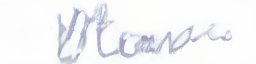

/content/DiffusionPen/image_samples/қазақ_style_214.png


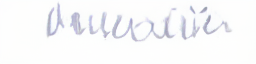

/content/DiffusionPen/image_samples/привет_style_214.png


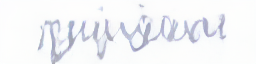

/content/DiffusionPen/image_samples/текст_style_214.png


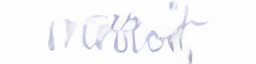

/content/DiffusionPen/image_samples/word_style_214.png


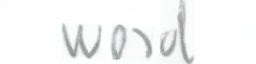

/content/DiffusionPen/image_samples/text_style_214.png


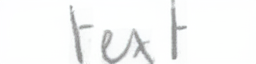

In [81]:
from PIL import Image
import matplotlib.pyplot as plt

imgs = [p for p in files if p.suffix.lower() in {".png", ".jpg", ".jpeg"}][:8]

for p in imgs:
    print(p)
    display(Image.open(p))

In [82]:
from pathlib import Path
import shutil

src = Path("/content/DiffusionPen/diffusionpen_hkr_pilot/models")
dst = Path("/content/DiffusionPen/backup_hkr_epoch1/models")

dst.mkdir(parents=True, exist_ok=True)

for name in ["ckpt.pt", "ema_ckpt.pt", "optim.pt"]:
    shutil.copy2(src / name, dst / name)

print("Backup epoch 1 saved")

Backup epoch 1 saved


In [83]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode train \
    --epochs 9 \
    --batch_size 1 \
    --num_workers 0 \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5 \
    --load_check True

Выходные данные были обрезаны до нескольких последних строк (5000).
DEBUG J: loss = 0.06626326590776443
DEBUG K: before backward
DEBUG L: backward OK
DEBUG batch 326: received
DEBUG A: batch moved to GPU
DEBUG B: before tokenizer
DEBUG C: tokenizer OK
DEBUG F: before VAE
DEBUG G: VAE OK torch.Size([1, 4, 8, 32])
DEBUG H: before UNet
DEBUG I: UNet forward OK torch.Size([1, 4, 8, 32])
DEBUG J: loss = 0.4914919137954712
DEBUG K: before backward
DEBUG L: backward OK
DEBUG batch 327: received
DEBUG A: batch moved to GPU
DEBUG B: before tokenizer
DEBUG C: tokenizer OK
DEBUG F: before VAE
DEBUG G: VAE OK torch.Size([1, 4, 8, 32])
DEBUG H: before UNet
DEBUG I: UNet forward OK torch.Size([1, 4, 8, 32])
DEBUG J: loss = 0.017000045627355576
DEBUG K: before backward
DEBUG L: backward OK
DEBUG batch 328: received
DEBUG A: batch moved to GPU
DEBUG B: before tokenizer
DEBUG C: tokenizer OK
DEBUG F: before VAE
DEBUG G: VAE OK torch.Size([1, 4, 8, 32])
DEBUG H: before UNet
DEBUG I: UNet forward OK torc

In [84]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5

/content/DiffusionPen
I0000 00:00:1791273950.184893   35903 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791273953.687139   35903 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Sampling mode: skipping GNHK dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: текст
style 214
five_styles [['r02/r02-038/r02-038-02-11.png', '641', 'along'], ['r02/r02-038/r02-038-02-10.png', '641', 'jogged'], ['r02/r02-038/r02-038-00-09.png', '641', 'there'], ['r02/r02-038/r02-038-04-02.png', '641', 'what'], ['r02/r02-038/r02-038-00-07.png', '641', "wasn't"]]
Saved: ./image_samples/текст_s


 текст
/content/DiffusionPen/image_samples/текст_style_214.png


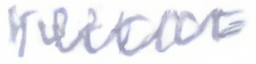


 привет
/content/DiffusionPen/image_samples/привет_style_214.png


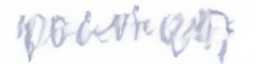


 қазақ
/content/DiffusionPen/image_samples/қазақ_style_214.png


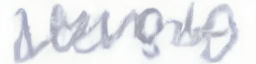


 Әлем
/content/DiffusionPen/image_samples/Әлем_style_214.png


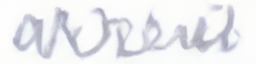

In [85]:
from pathlib import Path
from PIL import Image
from IPython.display import display

sample_dir = Path("/content/DiffusionPen/image_samples")

for word in ["текст", "привет", "қазақ", "Әлем"]:
    p = sample_dir / f"{word}_style_214.png"

    print("\n", word)
    print(p)

    if p.exists():
        display(Image.open(p))
    else:
        print("Файл не найден")

In [86]:
from pathlib import Path
import shutil

src = Path("/content/DiffusionPen/diffusionpen_hkr_pilot/models")
dst = Path("/content/DiffusionPen/backup_hkr_epoch10/models")

dst.mkdir(parents=True, exist_ok=True)

for name in ["ckpt.pt", "ema_ckpt.pt", "optim.pt"]:
    if (src / name).exists():
        shutil.copy2(src / name, dst / name)

print("Checkpoint после 10 эпох сохранён.")

Checkpoint после 10 эпох сохранён.


Найдено: 5
1337_001_005.jpg


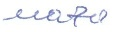

1337_002_001.jpg


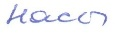

1337_002_003.jpg


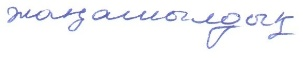

1337_002_005.jpg


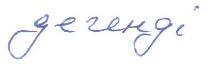

1337_003_001.jpg


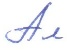

In [87]:
from pathlib import Path
from PIL import Image
from IPython.display import display

HKR_DIR = Path("/content/HKR_diffusionpen/train_words")

refs = sorted(HKR_DIR.glob("1337_*.jpg"))[:5]

print("Найдено:", len(refs))

for p in refs:
    print(p.name)
    display(Image.open(p))

In [88]:
!nl -ba /content/DiffusionPen/train.py | sed -n '855,925p'

   855	        
   856	        ema = EMA(0.995)
   857	        ema_model = copy.deepcopy(unet).eval().requires_grad_(False)
   858	        ema_model.load_state_dict(torch.load(f'{args.save_path}/models/ema_ckpt.pt', map_location=args.device))
   859	        ema_model.eval()
   860	        
   861	        if args.sampling_mode == 'single_sampling':
   862	            x_text = ['текст', 'привет', 'қазақ', 'Әлем']
   863	            for x_text in x_text:
   864	                print('Word:', x_text)
   865	                s = 214 # fixed style for reproduction
   866	                
   867	                print('style', s)
   868	                labels = torch.tensor([s]).long().to(args.device)
   869	                ema_sampled_images = diffusion.sampling(ema_model, vae, n=len(labels), x_text=x_text, labels=labels, args=args, style_extractor=feature_extractor, noise_scheduler=ddim, transform=transform, character_classes=None, tokenizer=tokenizer, text_encoder=text_encoder, run_idx=None)

In [89]:
%cd /content/DiffusionPen

!grep -R -n "def sampling(" . \
    --exclude-dir=.git \
    --exclude="train.py"

/content/DiffusionPen


In [90]:
%cd /content/DiffusionPen

!grep -R -n "def sampling" . \
    --include="*.py" \
    | head -30

/content/DiffusionPen
./train.py:185:    def sampling_loader(self, model, test_loader, vae, n, x_text, labels, args, style_extractor, noise_scheduler, mix_rate=None, cfg_scale=3, transform=None, character_classes=None, tokenizer=None, text_encoder=None):
./train.py:255:    def sampling(self, model, vae, n, x_text, labels, args, style_extractor, noise_scheduler, mix_rate=None, cfg_scale=3, transform=None, character_classes=None, tokenizer=None, text_encoder=None, run_idx=None):


In [91]:
%cd /content/DiffusionPen

!nl -ba train.py | sed -n '255,360p'

/content/DiffusionPen
   255	    def sampling(self, model, vae, n, x_text, labels, args, style_extractor, noise_scheduler, mix_rate=None, cfg_scale=3, transform=None, character_classes=None, tokenizer=None, text_encoder=None, run_idx=None):
   256	        model.eval()
   257	        tensor_list = []
   258	        
   259	        with torch.no_grad():
   260	            style_images = None
   261	            text_features = x_text #[x_text]*n
   262	            #print('text features', text_features.shape)
   263	            text_features = tokenizer(text_features, padding="max_length", truncation=True, return_tensors="pt", max_length=40).to(args.device)
   264	            if args.img_feat == True:
   265	                #pick random image according to specific style
   266	                with open('./writers_dict_train.json', 'r') as f:
   267	                    
   268	                    wr_dict = json.load(f)
   269	                reverse_wr_dict = {v: k for k, v in wr_dict.items

In [92]:
%cd /content/DiffusionPen
!nl -ba train.py | sed -n '338,405p'

/content/DiffusionPen
   338	                        st_imgs = []
   339	                        grid_imgs = []
   340	                        for im_idx, random_f in enumerate(five_styles):
   341	                            file_path = os.path.join(root_path, random_f[0])
   342	                            #print('file_path', file_path)
   343	                            
   344	                            try:
   345	                                img_s = Image.open(file_path).convert('RGB')
   346	                            except ValueError:
   347	                                # Handle the exception (e.g., print an error message)
   348	                                print(f"Error loading image from {file_path}")
   349	                                
   350	                                # Find a replacement image that is not corrupted
   351	                                replacement_idx = (im_idx + 1) % 5
   352	                                replacement_f = five_styl

In [94]:
!find /content -name "writer_dict_train_gnhk.json" -type f 2>/dev/null

/content/DiffusionPen/writer_dict_train_gnhk.json


In [95]:
import json
import glob

paths = glob.glob(
    "/content/**/writer_dict_train_gnhk.json",
    recursive=True
)

print("Найдено:", paths)

for path in paths:
    print("\nFILE:", path)
    with open(path, "r") as f:
        writer_map = json.load(f)

    print(writer_map)
    print("1337 ->", writer_map.get("1337"))

Найдено: ['/content/DiffusionPen/writer_dict_train_gnhk.json']

FILE: /content/DiffusionPen/writer_dict_train_gnhk.json
{'1337': 0, '635': 1, '506': 2, '1559': 3, '904': 4, '1814': 5, '1681': 6, '354': 7}
1337 -> 0


In [96]:
from pathlib import Path
import shutil

train_py = Path("/content/DiffusionPen/train.py")
backup_py = Path("/content/DiffusionPen/train_before_hkr_sampling.py")

# Сохраняем исходную версию перед изменением
if not backup_py.exists():
    shutil.copy2(train_py, backup_py)
    print("Backup создан:", backup_py)

code = train_py.read_text()

start_marker = """                #pick random image according to specific style
                with open('./writers_dict_train.json', 'r') as f:"""

end_marker = """                        st_imgs = []
                        grid_imgs = []"""

start = code.find(start_marker)
end = code.find(end_marker, start)

assert start != -1, "Не найдено начало IAM style-блока"
assert end != -1, "Не найден конец IAM style-блока"

replacement = """                # =========================================================
                # HKR STYLE REFERENCES
                # =========================================================
                hkr_style_group = "1337"
                root_path = "/content/HKR_diffusionpen/train_words"

                with open(
                    "/content/DiffusionPen/writer_dict_train_gnhk.json",
                    "r"
                ) as f:
                    hkr_writer_dict = json.load(f)

                hkr_label = int(hkr_writer_dict[hkr_style_group])

                # Используем внутренний label HKR style-group
                labels = torch.tensor(
                    [hkr_label] * n,
                    dtype=torch.long,
                    device=args.device
                )

                # Берём реальные изображения только этой style-group
                hkr_files = sorted([
                    f for f in os.listdir(root_path)
                    if f.startswith(hkr_style_group + "_")
                    and f.lower().endswith((".jpg", ".jpeg", ".png"))
                ])

                if len(hkr_files) < 5:
                    raise RuntimeError(
                        f"Для HKR style {hkr_style_group} "
                        f"найдено только {len(hkr_files)} изображений"
                    )

                # Одни и те же 5 reference images для воспроизводимости
                hkr_files = hkr_files[:5]

                print("HKR style group:", hkr_style_group)
                print("HKR internal label:", hkr_label)
                print("HKR five style references:")

                for fn in hkr_files:
                    print("   ", fn)

                # Код ниже ожидает имя картинки как random_f[0]
                five_styles = [[fn] for fn in hkr_files]

                # В текущем sampling эта опция выключена
                cor_im = False

"""

new_code = code[:start] + replacement + code[end:]
train_py.write_text(new_code)

print("Патч установлен.")

Backup создан: /content/DiffusionPen/train_before_hkr_sampling.py
Патч установлен.


In [97]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5

/content/DiffusionPen
  File "/content/DiffusionPen/train.py", line 315
    st_imgs = []
IndentationError: unexpected indent


In [98]:
from pathlib import Path
import shutil

src = Path("/content/DiffusionPen/train_before_hkr_sampling.py")
dst = Path("/content/DiffusionPen/train.py")

assert src.exists(), "Backup train.py не найден"

shutil.copy2(src, dst)

print("train.py восстановлен")

train.py восстановлен


In [99]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
code = p.read_text()

old = """                        print('five_styles', five_styles)
                        #five_styles = random.sample(matching_lines, 5)

                        cor_image_random = random.sample(matching_lines, 1)"""

new = """                        # ===== HKR references for adaptation diagnostic =====
                        hkr_style_group = "1337"
                        hkr_root = "/content/HKR_diffusionpen/train_words"

                        hkr_files = sorted([
                            f for f in os.listdir(hkr_root)
                            if f.startswith(hkr_style_group + "_")
                            and f.lower().endswith((".jpg", ".jpeg", ".png"))
                        ])

                        if len(hkr_files) < 5:
                            raise RuntimeError(
                                f"Only {len(hkr_files)} HKR references found"
                            )

                        # random_f[0] below must contain filename
                        five_styles = [[f] for f in hkr_files[:5]]

                        print("USING HKR STYLE:", hkr_style_group)
                        print("HKR five_styles:", five_styles)

                        # Not actually used because cor_im=False below,
                        # but keep the variable valid
                        cor_image_random = five_styles[:1]"""

assert old in code, "Участок для замены не найден"
code = code.replace(old, new, 1)

old_root = """                        root_path = './iam_data/words'
                        cor_im = False"""

new_root = """                        root_path = "/content/HKR_diffusionpen/train_words"
                        cor_im = False"""

assert old_root in code, "root_path не найден"
code = code.replace(old_root, new_root, 1)

p.write_text(code)

print("Минимальный HKR patch установлен")

Минимальный HKR patch установлен


In [100]:
!python -m py_compile /content/DiffusionPen/train.py

In [101]:
!nl -ba /content/DiffusionPen/train.py | sed -n '280,355p'

   280	    
   281	                        matching_lines = [line for line in train_data if line[1] == reverse_wr_dict[label_index] and len(line[2])>3]
   282	
   283	                        #pick the first 5 from matching lines
   284	                        
   285	                        if len(matching_lines) >= 5:
   286	                            #five_styles = matching_lines[:5]
   287	                            #pick first line and repeat
   288	                            #five_styles = [matching_lines[0]]*5
   289	                            five_styles = random.sample(matching_lines, 5)
   290	                            #five_styles = matching_lines_style[:5]
   291	                        else:
   292	                            matching_lines = [line for line in train_data if line[1] == reverse_wr_dict[label_index]]
   293	                            #print('matching lines', matching_lines)
   294	                            five_styles = matching_lines_style[:5]
   295

In [102]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
code = p.read_text()

old = """                s = 214 # fixed style for reproduction"""
new = """                s = 0 # HKR style_group 1337"""

assert old in code, "Строка s = 214 не найдена"
code = code.replace(old, new, 1)

p.write_text(code)

print("Теперь 1337 -> label 0")

Теперь 1337 -> label 0


In [103]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5

/content/DiffusionPen
I0000 00:00:1791274839.501685   39719 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791274842.869496   39719 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Sampling mode: skipping GNHK dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: текст
style 0
USING HKR STYLE: 1337
HKR five_styles: [['1337_001_005.jpg'], ['1337_002_001.jpg'], ['1337_002_003.jpg'], ['1337_002_005.jpg'], ['1337_003_001.jpg']]
Saved: ./image_samples/текст_style_0.png
Word: привет
style 0
USING HKR STYLE: 1337
HKR five_styles: [['1337_001_005.jpg'], ['1337_002_001.jpg'], ['133


TARGET: текст
FILE: /content/DiffusionPen/image_samples/текст_style_0.png


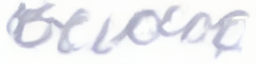


TARGET: привет
FILE: /content/DiffusionPen/image_samples/привет_style_0.png


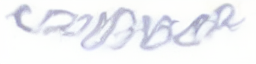


TARGET: қазақ
FILE: /content/DiffusionPen/image_samples/қазақ_style_0.png


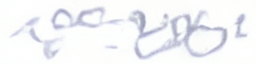


TARGET: Әлем
FILE: /content/DiffusionPen/image_samples/Әлем_style_0.png


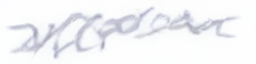

In [104]:
from pathlib import Path
from PIL import Image
from IPython.display import display

folder = Path("/content/DiffusionPen/image_samples")

for word in ["текст", "привет", "қазақ", "Әлем"]:
    p = folder / f"{word}_style_0.png"

    print("\nTARGET:", word)
    print("FILE:", p)

    if p.exists():
        display(Image.open(p))
    else:
        print("Файл не найден")

In [105]:
from pathlib import Path

p = Path("/content/DiffusionPen/train.py")
code = p.read_text()

code = code.replace(
    "x_text = ['текст', 'привет', 'қазақ', 'Әлем']",
    "x_text = ['кәсіпкерлік', 'болсақ', 'айналмалы', 'қаржыдан', 'текст', 'қазақ']"
)

p.write_text(code)

!python -m py_compile /content/DiffusionPen/train.py
print("OK")

OK


In [106]:
%cd /content/DiffusionPen

!python -u train.py \
    --dataset gnhk \
    --train_mode sampling \
    --sampling_mode single_sampling \
    --device cuda:0 \
    --save_path ./diffusionpen_hkr_pilot \
    --style_path ./style_models/iam_style_diffusionpen.pth \
    --stable_dif_path ./stable-diffusion-v1-5

/content/DiffusionPen
I0000 00:00:1791275078.587585   40750 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791275081.058647   40750 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
num_tokens 1
num_tokens 1
num of character classes 80
torch version 2.11.0+cu130
loading HKR through GNHK-compatible loader
Sampling mode: skipping GNHK dataset loading
Vocab size:  79
VAE is true
Sampling started....
unet loaded
Word: кәсіпкерлік
style 0
USING HKR STYLE: 1337
HKR five_styles: [['1337_001_005.jpg'], ['1337_002_001.jpg'], ['1337_002_003.jpg'], ['1337_002_005.jpg'], ['1337_003_001.jpg']]
Saved: ./image_samples/кәсіпкерлік_style_0.png
Word: болсақ
style 0
USING HKR STYLE: 1337
HKR five_styles: [['1337_001_005.jpg'], ['1337_002_001.


TARGET: кәсіпкерлік


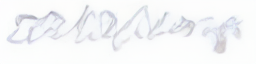


TARGET: болсақ


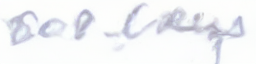


TARGET: айналмалы


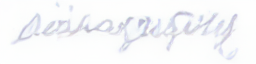


TARGET: қаржыдан


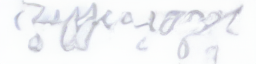


TARGET: текст


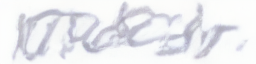


TARGET: қазақ


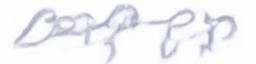

In [107]:
from pathlib import Path
from PIL import Image
from IPython.display import display

folder = Path("/content/DiffusionPen/image_samples")

words = [
    "кәсіпкерлік",
    "болсақ",
    "айналмалы",
    "қаржыдан",
    "текст",
    "қазақ",
]

for word in words:
    p = folder / f"{word}_style_0.png"
    print("\nTARGET:", word)

    if p.exists():
        display(Image.open(p))
    else:
        print("Не найден:", p)